In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

(720, 720, 3)


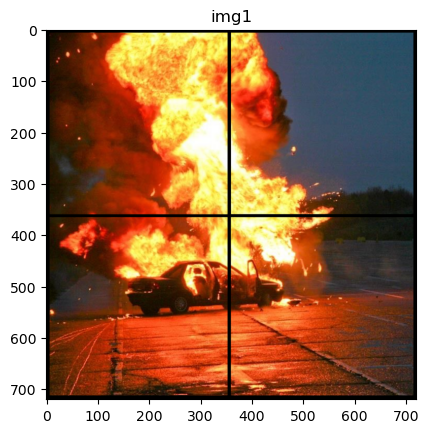

In [ ]:
img1 = plt.imread("Assets/Meledak.PNG")
plt.imshow(img1)
plt.title("img1")
print(img1.shape)

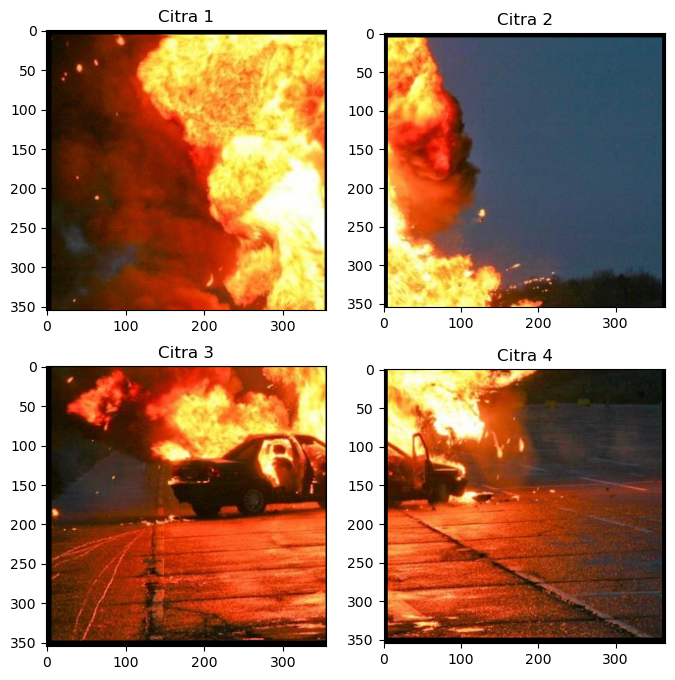

In [ ]:
def fungsi_empat_S(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

bagian_atas = fungsi_empat_S(img1, 0, 355, mode='H')
bagian_bawah = fungsi_empat_S(img1, 365, 730, mode='H')

citra_1 = fungsi_empat_S(bagian_atas, 0, 355, mode='V')
citra_2 = fungsi_empat_S(bagian_atas, 355, 730, mode='V')

citra_3 = fungsi_empat_S(bagian_bawah, 0, 355, mode='V')
citra_4 = fungsi_empat_S(bagian_bawah, 355, 730, mode='V') 


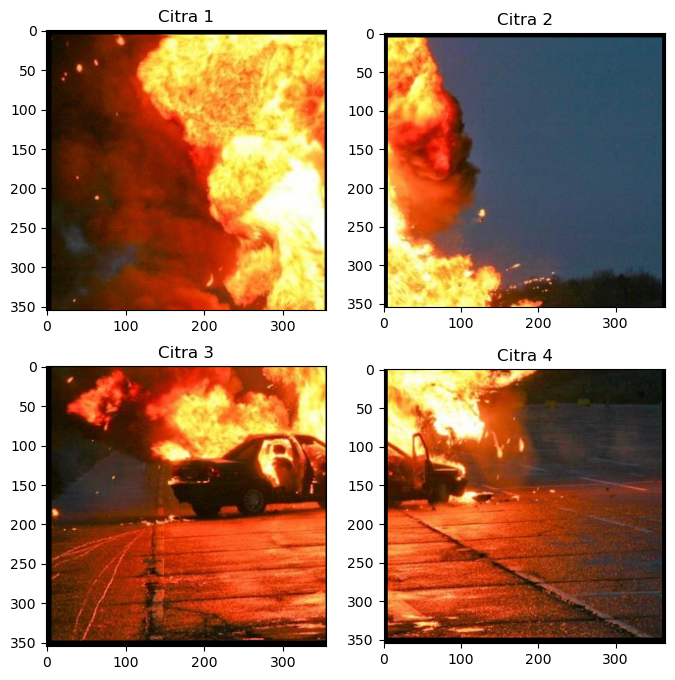

In [24]:
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(citra_1)

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(citra_2)

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(citra_3)

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(citra_4)

plt.show()

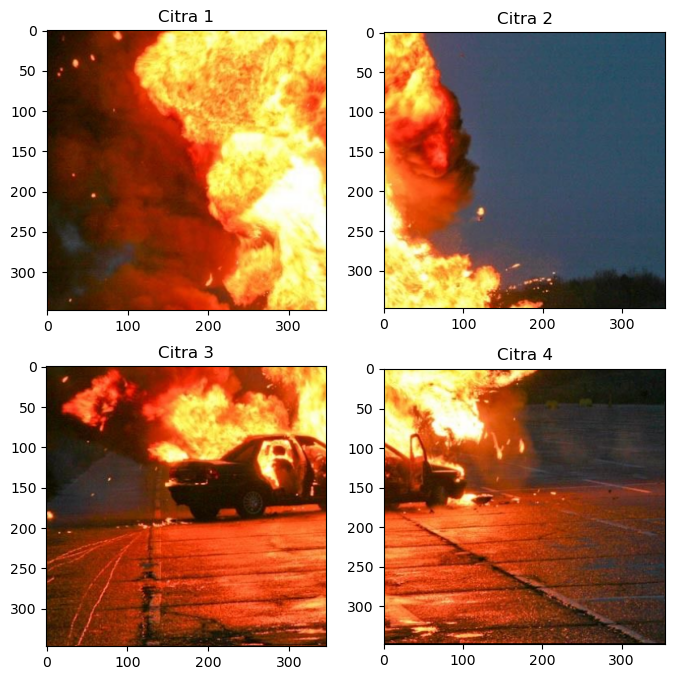

In [40]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex]

citra_1_int = (citra_1 * 255).astype(int)
citra_2_int = (citra_2 * 255).astype(int)
citra_3_int = (citra_3 * 255).astype(int)
citra_4_int = (citra_4 * 255).astype(int)

def crop_hitam(image):
    if image.dtype == float:
        image = (image * 255).astype(int)
    
    mask = image > 0
    baris = np.any(mask, axis=1)
    kolom = np.any(mask, axis=0)
    
    if not np.any(baris) or not np.any(kolom):
        return image
    
    y1, y2 = np.where(baris)[0][[0, -1]]
    x1, x2 = np.where(kolom)[0][[0, -1]]
    return image[y1:y2+1, x1:x2+1]
zoom1 = crop_hitam(citra_1_int)
zoom2 = crop_hitam(citra_2_int)
zoom3 = crop_hitam(citra_3_int)
zoom4 = crop_hitam(citra_4_int)

plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.title("Citra 1")
plt.imshow(zoom1)

plt.subplot(2, 2, 2)
plt.title("Citra 2")
plt.imshow(zoom2)

plt.subplot(2, 2, 3)
plt.title("Citra 3")
plt.imshow(zoom3)

plt.subplot(2, 2, 4)
plt.title("Citra 4")
plt.imshow(zoom4)

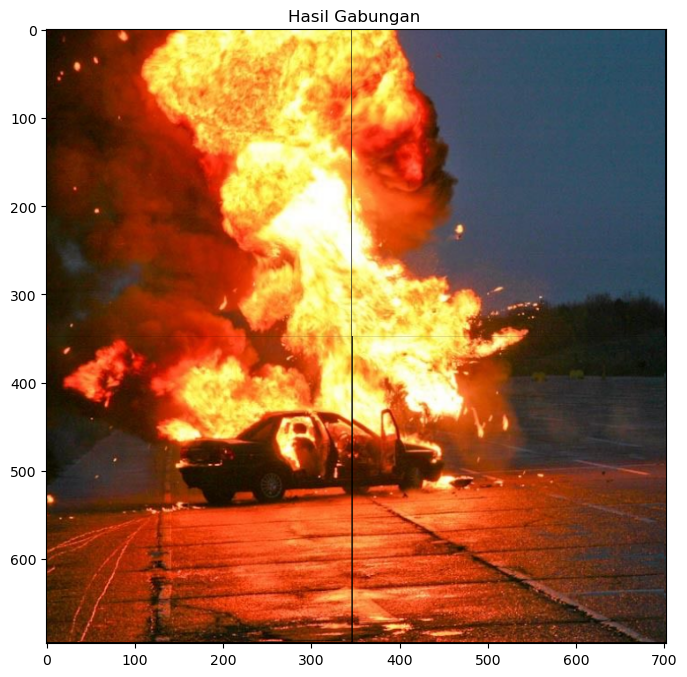

In [ ]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], 
citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 
0:citra2.shape[1]] = citra2 
     
    return gabungan 

merge_1 = merge_image(zoom1,zoom2 , orientation='H')
merge_2 = merge_image(zoom3,zoom4 ,orientation='H')
merge_final = merge_image(merge_1,merge_2, orientation='V')
plt.figure(figsize=(8, 8))
plt.title("Hasil Gabungan ")
plt.imshow(merge_final)
plt.show()

In [66]:
def ekualisasi(citra): 
    height, width = citra.shape 
 
    hist = np.zeros(256, dtype=int) 
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0] 
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) 
    hasil = np.zeros_like(citra, dtype=np.uint8) 
    return hasil 
